In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('resnet101')

In [14]:
model, params = MLFlowRegistry().load_model('models:/crowd_counting/52')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [3]:
params

BaseParams(image_size=None, crop_size=384, label_scaler=1000, aug_factor=None, num_ops=None, backbone='efficientnet-b2', model_class='MAnet', backbone_weights='imagenet', decoder_attention_type=None, trainable_backbone=False, neck_out_channels=None, dropout=None, batch_size=8, lr=0.00065, l2_reg=0.0001, lr_schedule='clipped_exp', monitor_metric='val_nae', grad_accumulation=1, grad_clip=None, scheduler_kwargs={'decay_rate': 0.96, 'min_lr_pct': 0.01}, suggested_params=False, epochs=60, padding_multiple=32, dataset='part_A', train_size=240, unfrozen_blocks=None, optimizer_config={}, extra={})

In [5]:
# import numpy as np
# dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(torch.randn(2, 3, 704, 1056))

(tensor([554.0131, 556.7980]),
 tensor([[[0.0009, 0.0009, 0.0008,  ..., 0.0007, 0.0007, 0.0007],
          [0.0008, 0.0009, 0.0008,  ..., 0.0006, 0.0007, 0.0007],
          [0.0011, 0.0011, 0.0009,  ..., 0.0007, 0.0008, 0.0007],
          ...,
          [0.0009, 0.0008, 0.0007,  ..., 0.0007, 0.0005, 0.0006],
          [0.0008, 0.0008, 0.0007,  ..., 0.0007, 0.0006, 0.0007],
          [0.0007, 0.0007, 0.0007,  ..., 0.0007, 0.0007, 0.0008]],
 
         [[0.0009, 0.0008, 0.0008,  ..., 0.0007, 0.0007, 0.0007],
          [0.0009, 0.0008, 0.0008,  ..., 0.0006, 0.0007, 0.0007],
          [0.0009, 0.0009, 0.0009,  ..., 0.0005, 0.0007, 0.0007],
          ...,
          [0.0009, 0.0009, 0.0007,  ..., 0.0006, 0.0006, 0.0006],
          [0.0007, 0.0008, 0.0007,  ..., 0.0007, 0.0007, 0.0007],
          [0.0007, 0.0007, 0.0007,  ..., 0.0006, 0.0007, 0.0007]]]))

In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='test')

182 images found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/images
182 h5 files found in /teamspace/lightning_storage/datasets/ShanghaiTech/part_A/test_data/ground-truth-h5


In [4]:
model.evaluate(datamodule)

tensor([433.1755], device='cuda:0') tensor([171.8294], device='cuda:0')
tensor([421.6952], device='cuda:0') tensor([497.0637], device='cuda:0')
tensor([354.2208], device='cuda:0') tensor([381.9256], device='cuda:0')
tensor([419.5146], device='cuda:0') tensor([210.3973], device='cuda:0')
tensor([272.1573], device='cuda:0') tensor([217.3769], device='cuda:0')
tensor([476.9132], device='cuda:0') tensor([427.6055], device='cuda:0')
tensor([1611.0928], device='cuda:0') tensor([1163.2383], device='cuda:0')
tensor([232.0280], device='cuda:0') tensor([257.0872], device='cuda:0')
tensor([1209.8558], device='cuda:0') tensor([1225.8103], device='cuda:0')
tensor([228.0434], device='cuda:0') tensor([288.4334], device='cuda:0')
tensor([174.9511], device='cuda:0') tensor([175.6181], device='cuda:0')
tensor([360.6785], device='cuda:0') tensor([373.5144], device='cuda:0')
tensor([950.2635], device='cuda:0') tensor([1063.9664], device='cuda:0')
tensor([803.4426], device='cuda:0') tensor([1016.6429], dev

tensor([395.1490], device='cuda:0') tensor([376.9098], device='cuda:0')
tensor([220.6055], device='cuda:0') tensor([367.9316], device='cuda:0')
tensor([1641.6116], device='cuda:0') tensor([2244.0696], device='cuda:0')
tensor([102.6314], device='cuda:0') tensor([95.6099], device='cuda:0')
tensor([1567.6741], device='cuda:0') tensor([1358.6505], device='cuda:0')
tensor([224.2202], device='cuda:0') tensor([250.4240], device='cuda:0')
tensor([57.5918], device='cuda:0') tensor([63.7583], device='cuda:0')
tensor([157.0617], device='cuda:0') tensor([185.4946], device='cuda:0')
tensor([252.3336], device='cuda:0') tensor([240.0586], device='cuda:0')
tensor([554.6675], device='cuda:0') tensor([468.9125], device='cuda:0')
tensor([129.4309], device='cuda:0') tensor([146.8988], device='cuda:0')
tensor([170.7406], device='cuda:0') tensor([240.4309], device='cuda:0')


{'MAE': 80.06059265136719,
 'NAE': 0.22111821174621582,
 'RMSE': 127.46940612792969}

In [ ]:
# from src.models.ensembled_model import EnsembledCrowdCounter

# model = mlflow.pyfunc.load_model('models:/crowd_counting/52')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=6)
sample.shape

torch.Size([1, 3, 704, 1024])

In [15]:
from torchvision.transforms import v2
from PIL import Image

from src.data import transform_sample
original_image = Image.open('/teamspace/studios/this_studio/workspace/crowd_counting/testing_images/input/hama_2025_2.jpg').convert('RGB')
image = transform_sample.preprocess(original_image, params)

In [16]:
result  = model.predict(image)
result = (float(result[0][0]), result[1])
result

(2068.69091796875,
 tensor([[[0.0005, 0.0004, 0.0003,  ..., 0.0003, 0.0004, 0.0004],
          [0.0004, 0.0003, 0.0002,  ..., 0.0002, 0.0003, 0.0003],
          [0.0004, 0.0002, 0.0001,  ..., 0.0002, 0.0003, 0.0004],
          ...,
          [0.0004, 0.0003, 0.0002,  ..., 0.0002, 0.0003, 0.0004],
          [0.0005, 0.0003, 0.0002,  ..., 0.0002, 0.0003, 0.0004],
          [0.0005, 0.0005, 0.0003,  ..., 0.0003, 0.0003, 0.0004]]],
        device='cuda:0'))

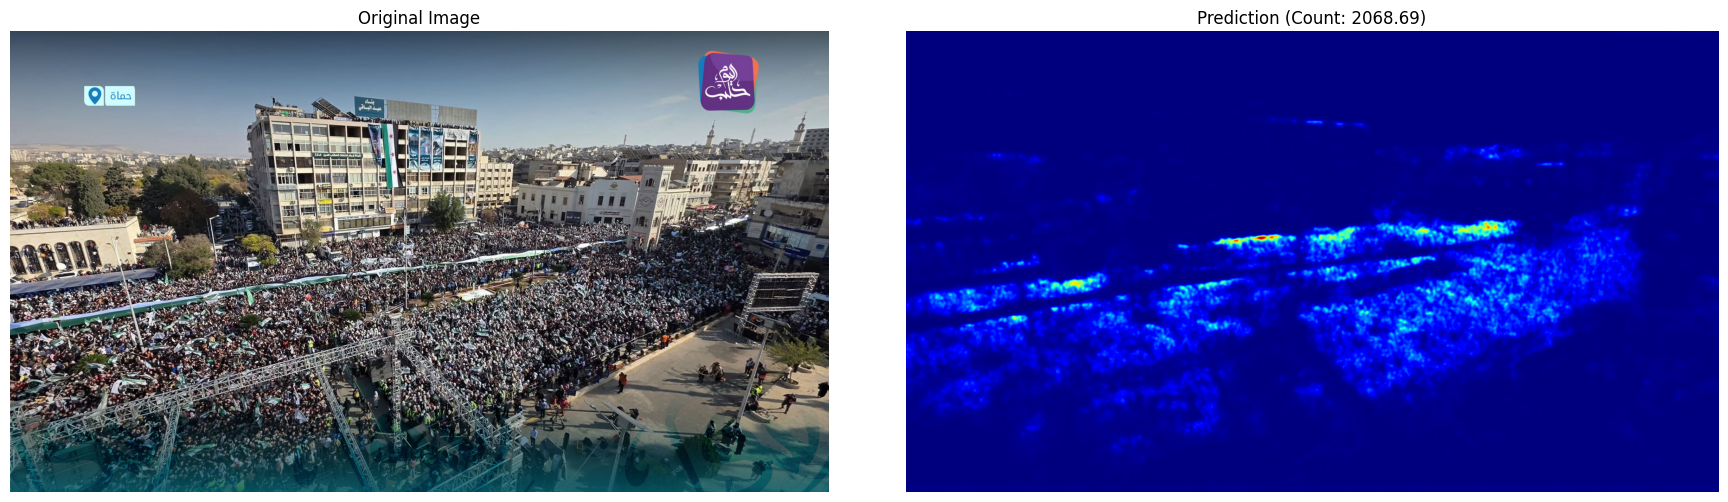

In [19]:
vis.visualize_sample(original_image, pred=result, cmap='jet')

In [ ]:
vis.visualize_model_graph(model.model, sample=sample)